In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from ipywidgets import interactive

In [2]:
def f2d(X1,X2):
    # Rastrigin function 2d
    return 20 + X1**2 + X2**2 - 10 * np.cos(2 * np.pi * X1) - 10 * np.cos(2 * np.pi * X2)

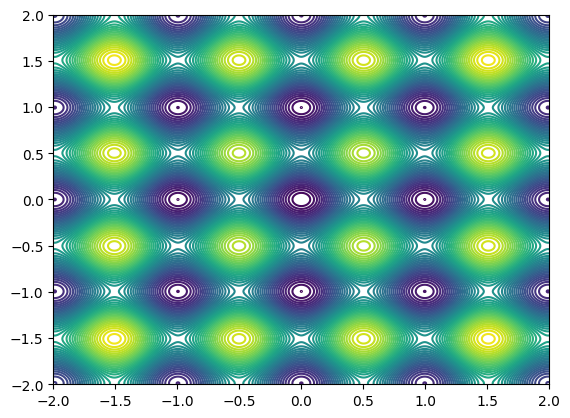

In [3]:
LB = -2
HB = 2

X1 = np.linspace(LB, HB, 1000)
X2 = np.linspace(LB, HB, 1000)
XX1, XX2 = np.meshgrid(X1, X2)
Y = f2d(XX1, XX2)

YMIN = np.min(Y)
YMAX = np.max(Y)

def plot_f2d():
    global X1, X2, Y
    plt.contour(X1, X2, Y, levels=50, zorder=0, cmap='viridis')
plot_f2d()

In [4]:
# interactive 3d plot
def plot_f2d_3d(elev=30, azim=30):
    global X1, X2, Y
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX1, XX2, Y, cmap='viridis')
    ax.view_init(elev=elev, azim=azim)
    plt.show()
interactive(plot_f2d_3d, elev=(0, 90), azim=(0, 360))

interactive(children=(IntSlider(value=30, description='elev', max=90), IntSlider(value=30, description='azim',…

In [5]:
N = 50
np.random.seed(100)
pso_particles = np.random.uniform(LB, HB, (N, 2))
pso_particles_fitness = f2d(pso_particles[:,0], pso_particles[:,1])

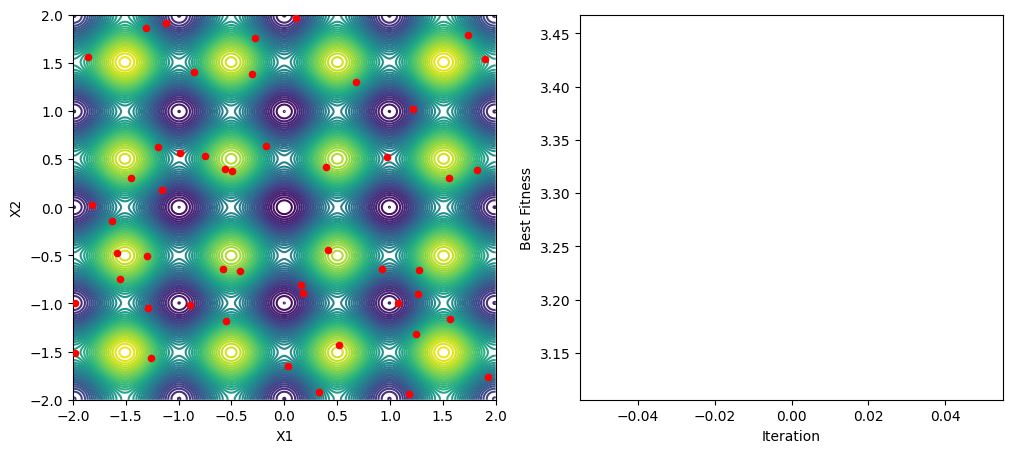

In [6]:
history = []
def plot_f2d_pso():
    global X1, X2, Y, pso_particles, pso_particles_fitness, history
    figure = plt.figure(figsize=(12, 5))
    ax1 = figure.add_subplot(121)
    ax1.contour(X1, X2, Y, levels=50, zorder=0, cmap='viridis')
    ax1.scatter(
        pso_particles[:,0],
        pso_particles[:,1],
        color='red',
        s=20,
        zorder=10
    )
    ax1.set_xlim(LB, HB)
    ax1.set_ylim(LB, HB)
    ax1.set_xlabel('X1')
    ax1.set_ylabel('X2')
    
    history.append(np.min(pso_particles_fitness))
    ax2 = figure.add_subplot(122)
    ax2.plot(history, color='blue')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Best Fitness')

plot_f2d_pso()

In [7]:
pso_particles_vel = np.random.uniform(-1, 1, (N,2))
pso_particles_pbest = pso_particles.copy()
pso_particles_pbest_fitness = pso_particles_fitness.copy()
pso_global_best_pos = pso_particles[np.argmin(pso_particles_fitness)]
pso_global_best_fitness = np.min(pso_particles_fitness)

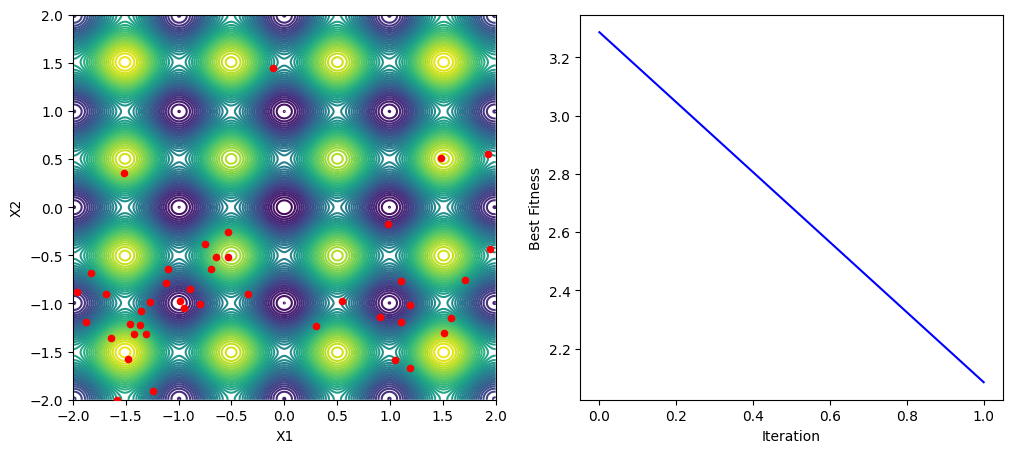

In [8]:
w = 0.5
C1 = 1.8
C2 = 2
for i in range(N):
    # PSO equations
    pso_particles_vel[i] = w * pso_particles_vel[i] + \
                           C1 * (pso_particles_pbest[i] - pso_particles[i]) * np.random.random() + \
                           C2 * (pso_global_best_pos - pso_particles[i]) * np.random.random()
    pso_particles[i] += pso_particles_vel[i]
    pso_particles_fitness[i] = f2d(pso_particles[i,0], pso_particles[i,1])
    if pso_particles_fitness[i] < pso_particles_pbest_fitness[i]:
        pso_particles_pbest[i] = pso_particles[i]
        pso_particles_pbest_fitness[i] = pso_particles_fitness[i]
        if pso_particles_pbest_fitness[i] < pso_global_best_fitness:
            pso_global_best_pos = pso_particles_pbest[i]
            pso_global_best_fitness = pso_particles_pbest_fitness[i]
plot_f2d_pso()

<Figure size 640x480 with 0 Axes>

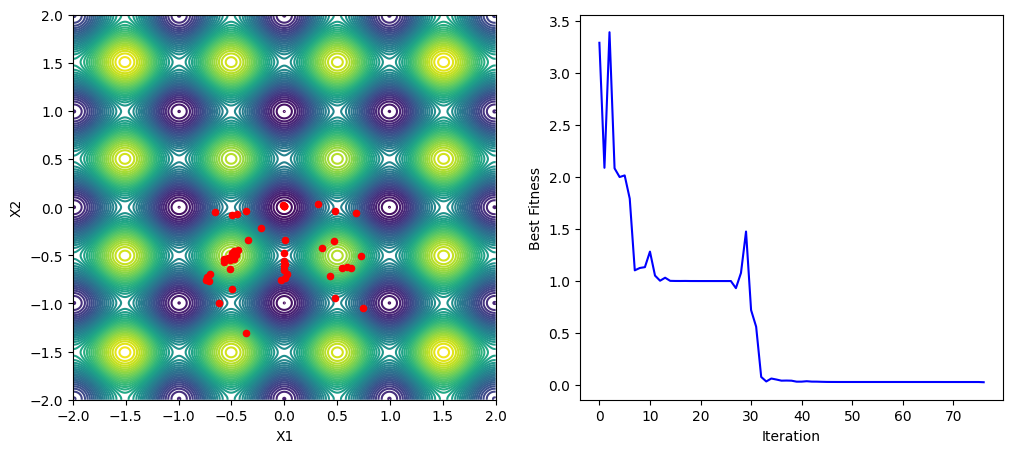

Global best fitness: 0.002046 at position [0.00154168 0.0028172 ] after 76 iterations


In [9]:
max_vel = 0.1
for k in range(100):
    for i in range(N):
        # PSO equations
        pso_particles_vel[i] = 0.5 * pso_particles_vel[i] + \
                            1.8 * (pso_global_best_pos - pso_particles[i]) * np.random.random() + \
                            2 * (pso_particles_pbest[i] - pso_particles[i]) * np.random.random()
        # len of velocity vector is limited to max_vel
        len_vel = np.linalg.norm(pso_particles_vel[i])
        if len_vel > max_vel:
            pso_particles_vel[i] = pso_particles_vel[i] / len_vel * max_vel
        pso_particles[i] += pso_particles_vel[i]
        pso_particles_fitness[i] = f2d(pso_particles[i,0], pso_particles[i,1])
        if pso_particles_fitness[i] < pso_particles_pbest_fitness[i]:
            pso_particles_pbest[i] = pso_particles[i]
            pso_particles_pbest_fitness[i] = pso_particles_fitness[i]
            if pso_particles_pbest_fitness[i] < pso_global_best_fitness:
                pso_global_best_pos = pso_particles_pbest[i]
                pso_global_best_fitness = pso_particles_pbest_fitness[i]
    if pso_global_best_fitness < 1e-2:
        print(f'Global best fitness: {pso_global_best_fitness:.6f} at position {pso_global_best_pos} after {k+1} iterations')
        break
    plt.clf()
    clear_output(wait=True)
    plot_f2d_pso()
    plt.pause(0.1)